In [2]:
import matplotlib.pyplot as plt
import numpy as np
from numpy.linalg import norm

In [3]:
import random
random.seed(44)
def prep_linear_data(X, a=1, b=0, error=8):
    y = np.empty_like(X, dtype=np.float64)
    for x in X:
        y[x] = a*x + b + random.uniform(0, error * a)
    return y

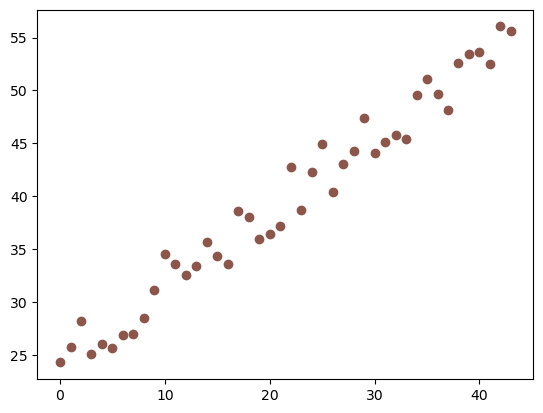

In [4]:
n = 44
x = np.array(range(n))
y = prep_linear_data(x, a=0.7, b=22)
plt.plot(y, color='tab:brown', marker='o', linewidth=0)
plt.show()

In [5]:
def srednia(T):
    result = 0
    ilosc = 0
    for t in T:
        result += t
        ilosc += 1
    if ilosc == 0:
        return 0
    return result / ilosc


In [6]:
## Calculate using least-squares method
x_ = srednia(x)
y_ = srednia(y)
b1 = np.dot(x - x_, y - y_) / norm(x - x_) ** 2
b0 = y_ - b1 * x_

y_pred = prep_linear_data(x, a=b1, b=b0, error=0)
var = norm(y_pred - y) ** 2/ n - 1
print("Variance: ", var)

Variance:  1.8513394425007155


B0:  23.952218497402892  B1:  0.7241075058174875
<class 'numpy.ndarray'>


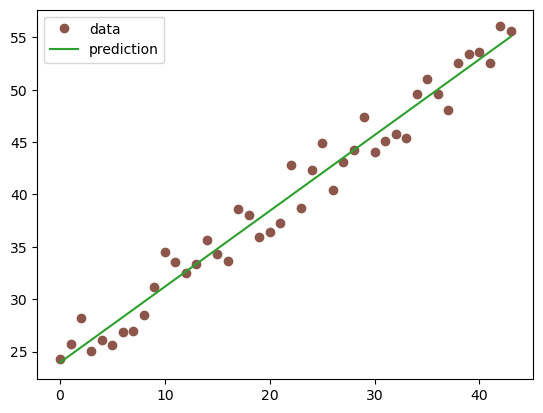

In [7]:
print("B0: ", b0, " B1: ", b1)
print(type(y_pred))
plt.plot(x, y, color='tab:brown', marker='o', linewidth=0, label='data')
plt.plot(x, y_pred, color='tab:green', label='prediction')
plt.legend()
plt.show()

In [8]:
## Same thing using scikit-learn
from sklearn import linear_model
model = linear_model.LinearRegression()
model.fit(x.reshape(-1,1), y)
print(model.coef_)

[0.72410751]
